# Simple single model

Shown in clear way

In [14]:
import matplotlib.pyplot as plt
import numpy as np

In [15]:
# all given in SI units
params = {
    'BOX' : {  
        'xy_min' : -15e-02,
        'xy_max' : 15e-02,
        'z_min'  : -5e-02,
        'z_max'  : 15e-02
    },
    'SOLVER' : {
                'mesh_dx' : 0.25e-02,
                'mesh_dy' : 0.25e-02,
                'mesh_dz' : 0.25e-02
            },
    'SOURCE' : {
                'wavelength'   : 2e-02, #in m // corresponds to 15 GHz
                'span'         : 0,
                'polarization' : 'x',
                'direction'    : 'FWD',
                'position'     : -5e-02
            },
    'STRUCTURE' : {
                'period' : 1e-02, #in m // corresponds to half wavelength
                'size' : 5 # For generation symmetric (2*size+1)x(2*size+1) coordinate grid centered at origin
                },
    'UNIT' : {
                'height' : 0.01 # in m
            }
}

print(params)

{'BOX': {'xy_min': -0.15, 'xy_max': 0.15, 'z_min': -0.05, 'z_max': 0.15}, 'SOLVER': {'mesh_dx': 0.0025, 'mesh_dy': 0.0025, 'mesh_dz': 0.0025}, 'SOURCE': {'wavelength': 0.02, 'span': 0, 'polarization': 'x', 'direction': 'FWD', 'position': -0.05}, 'STRUCTURE': {'period': 0.01, 'size': 5}, 'UNIT': {'height': 0.01}}


In [16]:
from lib4lum import phase_profiles

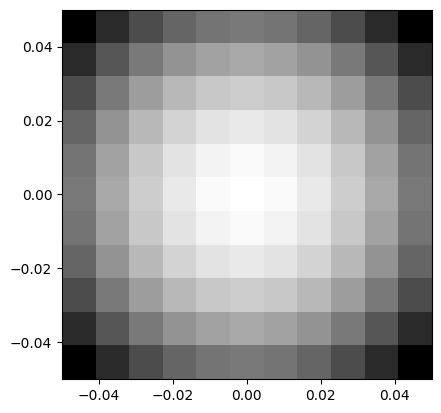

In [17]:
phase, X, Y = phase_profiles.lens_profile(
                            F =      5*params['SOURCE']['wavelength'], # 5 wavelegth
                            wl =     params['SOURCE']['wavelength'], 
                            period = params['STRUCTURE']['period'],
                            size =   params['STRUCTURE']['size'])

fig, ax = plt.subplots(1,1)
im = ax.imshow(phase, origin = 'lower')
im.set_cmap('gray')
im.set_extent([X[0,0], X[0,-1], Y[0,0], Y[-1,0]])

Let us assume only 2 radii are presented (for 0 and pi i.e)

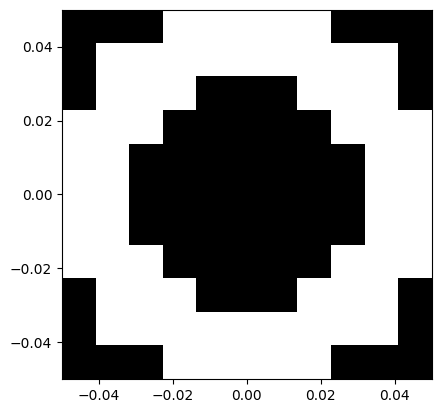

In [18]:
phase = phase_profiles.quantize(phase, 2)

fig, ax = plt.subplots(1,1)
im = ax.imshow(phase, origin = 'lower')
im.set_cmap('gray')
im.set_extent([X[0,0], X[0,-1], Y[0,0], Y[-1,0]])

0 : 3.18 mm

pi : 2.86 mm

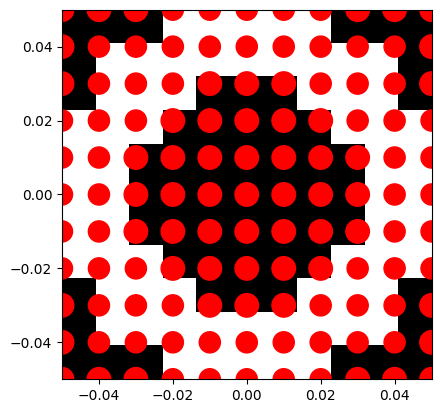

In [19]:
radii = phase_profiles.get_unit(phase_train = [0, np.pi],
                                radii_train = [3.18e-03, 2.86e-03],
                                phase_target = phase)

fig, ax = plt.subplots(1,1)
im = ax.imshow(phase, origin = 'lower')
im.set_cmap('gray')
im.set_extent([X[0,0], X[0,-1], Y[0,0], Y[-1,0]])

for i in range(np.shape(radii)[0]):
    for j in range(np.shape(radii)[1]):
        circle = plt.Circle((X[i,j], Y[i,j]), radius = radii[i,j], color='r')
        ax.add_patch(circle)

In [20]:
import lumapi
from lib4lum import model_generator

client = lumapi.FDTD(hide = False) #to hide window flag False

In [21]:
model_generator.add_solver(client, params, 
           simulation_time = 0.4e-06,
           z_min = -16e-02,
           z_max = 16e-02,
           mesh_type = 'auto non-uniform')
    

In [22]:
model_generator.add_source_plane(client, params, z = -15e-02)

In [23]:
def add_structure(client, X, Y, radii, **kwargs):
    client.putv('X_arr', X.flatten())
    client.putv('Y_arr', Y.flatten())
    client.putv('R_arr', radii.flatten())
    client.putv('N_sq', np.shape(X)[0]*np.shape(X)[1])

    if kwargs:
        for key, value in kwargs.items():
            client.putv(key, value)

    script = '''
    addstructuregroup; set("name", "Bottom_disk");
    addstructuregroup; set("name", "Spacer");
    addstructuregroup; set("name", "Top_disk");

    for (i = 1:N_sq){
    addcircle;
    set("x", X_arr(i)); set("y", Y_arr(i));
    set("z min", 0); set("z max", h_d);
    set("radius", R_arr(i));
    set("name", "Bot_disk_" + num2str(i));
    set("index", n_d);
    addtogroup("Bottom_disk");

    addcircle;
    set("x", X_arr(i)); set("y", Y_arr(i));
    set("z min", h_d); set("z max", h_d + h_s);
    set("radius", R_arr(i));
    set("name", "Spacer_" + num2str(i));
    set("index", n_s);
    addtogroup("Spacer");

    addcircle;
    set("x", X_arr(i)); set("y", Y_arr(i));
    set("z min", h_d + h_s); set("z max", 2*h_d + h_s);
    set("radius", R_arr(i));
    set("name", "Top_disk_" + num2str(i));
    set("index", n_d);
    addtogroup("Top_disk");
    }
    '''

    client.eval(script)

add_structure(client, X, Y, radii, 
              h_d = 10e-03,
              h_s = 5.2e-03,
              n_d = np.sqrt(11),
              n_s = np.sqrt(2.4))

In [24]:
model_generator.add_monitor_profile(client, '2D X')
model_generator.add_monitor_profile(client, '2D Y')
    

In [25]:
client.save('Simple_Single_Lens.fsp')
client.run()

In [26]:
client.save('Simple_Single_Lens.fsp')
client.close()